In [ ]:
from google.colab import files
files.upload()
#

In [ ]:
!unzip brain_tumor_dataset.zip

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Image size and batch size
img_size = 224
batch_size = 32

# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "/content/brain_tumor_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "/content/brain_tumor_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# CNN Model
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate model
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5172 - loss: 1.0742 - val_accuracy: 0.7200 - val_loss: 0.6459
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8177 - loss: 0.5609 - val_accuracy: 0.7200 - val_loss: 0.6205
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7537 - loss: 0.4984 - val_accuracy: 0.7400 - val_loss: 0.5169
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8473 - loss: 0.4239 - val_accuracy: 0.7400 - val_loss: 0.5010
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8374 - loss: 0.3718 - val_accuracy: 0.7400 - val_loss: 0.4530
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8621 - loss: 0.3169 - val_accuracy: 0.7800 - val_loss: 0.4219
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9064 - loss: 0.2364 - val_accuracy: 0.8400 - val_loss: 0.4761
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.9655 - loss: 0.1252 - val_accuracy: 0.8000 - val_loss: 0.6828
Epoch 9/

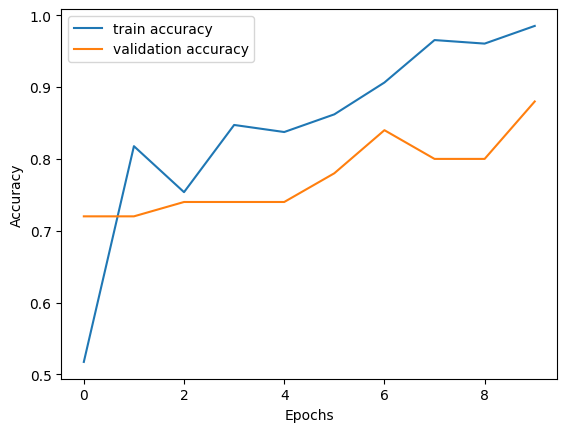

In [4]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
